## Auto loan prediction

In [3]:
# load relevant libraries
library(tidyverse)
library(caret)
library(glmnet)
library(dplyr)
library(ggplot2)
library(forcats)
library(stargazer)
library(e1071)
library(ROCR)

# install.packages("doParallel")
library(doParallel)
registerDoParallel(cores = 4)

In [4]:
data_dictionary = read.csv("data/Data_Dictionary.csv")

data_dictionary

Variable,Description
<chr>,<chr>
ID,Client Loan application ID
Client_Income,Client Income in $
Car_Owned,Any Car owned by client before applying for the loan for another car (0 means No and 1 means otherwise)
Bike_Owned,Any bike owned by client (0 means No and 1 means otherwise)
Active_Loan,Any other active loan at the time of aplication of loan (0 means No and 1 means otherwise)
House_Own,Any house owned by client (0 means No and 1 means otherwise)
Child_Count,Number of children the client has
Credit_Amount,Credit amount of the loan in $
Loan_Annuity,Loan annuity in $


In [5]:
data = read.csv("data/Train_Dataset.csv")
testDf = read.csv("data/Test_Dataset.csv")
str(data)
str(testDf)

# Convert the following to numeric
to_num = c('Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 
           'Registration_Days', 'ID_Days', 'Mobile_Tag', 'Score_Source_3') 

data[, to_num] = lapply(data[, to_num],as.numeric)
testDf[, to_num] = lapply(testDf[, to_num],as.numeric)
# Client_Occupation set blank to None, leave NA


to_factor = c('Application_Process_Hour', 'Application_Process_Day', 'Accompany_Client', 'Client_Income_Type',
             'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 
              'Client_Housing_Type','Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 
              'Type_Organization')

data[, to_factor] = lapply(data[, to_factor],as.factor)
testDf[, to_factor] = lapply(testDf[, to_factor],as.factor)


#Own house age to 0, Own_House will indicate if missing.

'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : chr  "6750" "20250" "18000" "15750" ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : chr  "61190.55" "15282" "59527.35" "53870.4" ...
 $ Loan_Annuity              : chr  "3416.85" "1826.55" "2788.2" "2295.45" ...
 $ Accompany_Client          : chr  "Alone" "Alone" "Alone" "Alone" ...
 $ Client_Income_Type        : chr  "Commercial" "Service" "Service" "Retired" ...
 $ Client_Education          : chr  "Secondary" "Graduation" "Graduation dropout" "Secondary" ...
 $ Client_Marital_Status     : chr  "M" "M

Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(testDf[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(testDf[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(testDf[, to_num], as.numeric):
“NAs introduced

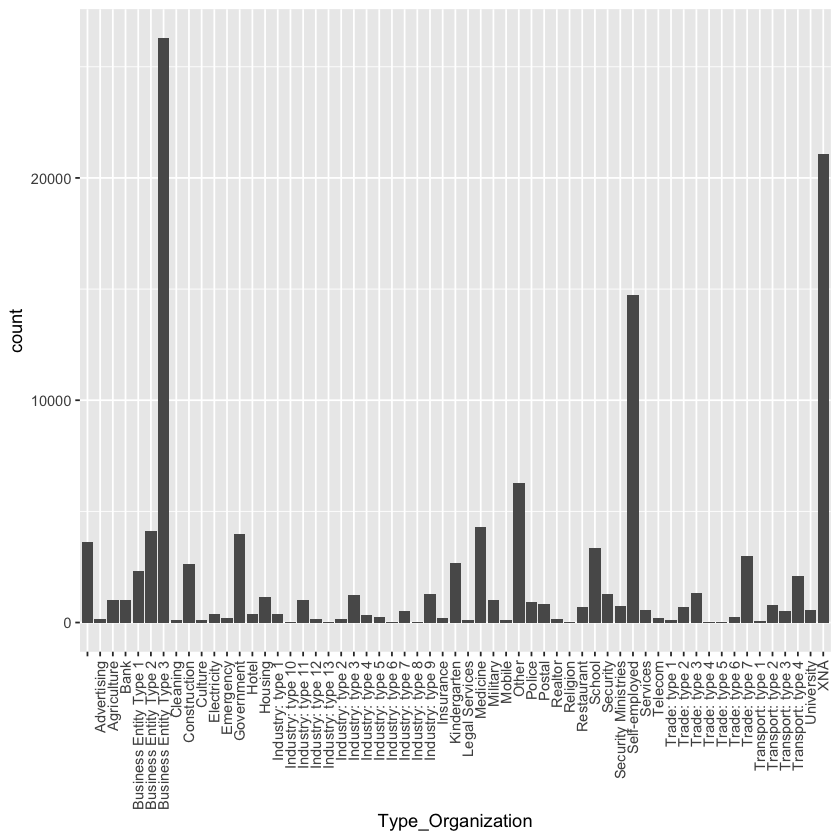

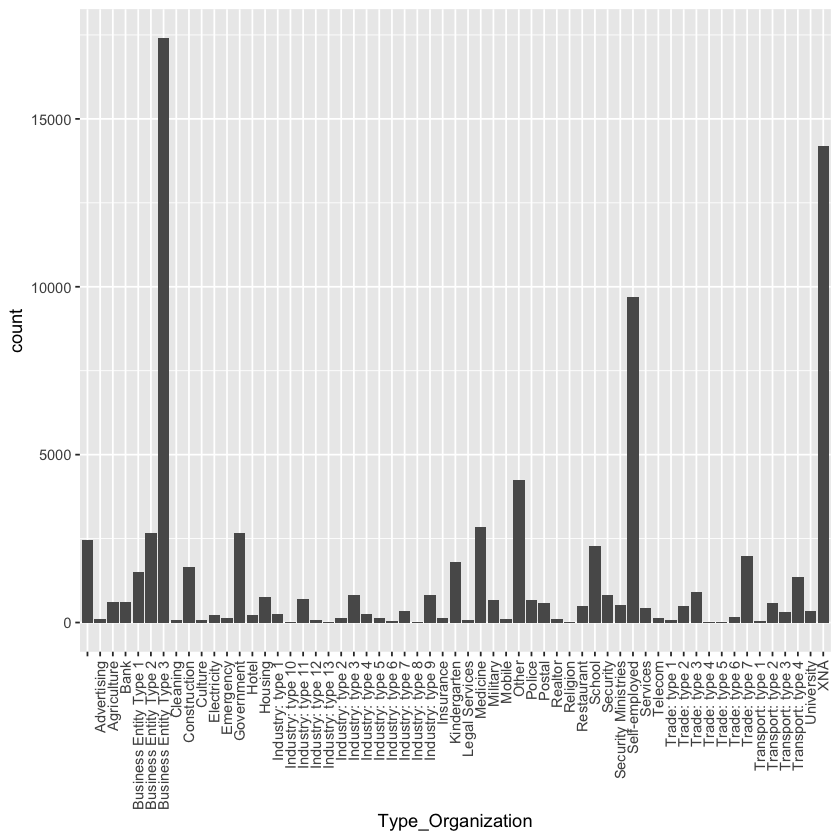

In [6]:
# Distribution of the 59 levels of the Type_Organization factor - Training Data
ggplot(data) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Distribution of the 59 levels of the Type_Organization factor -- Test Data
ggplot(testDf) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [7]:
# Perform LASSO to identify categories to merge for Type Organization 

x_train <- model.matrix( ~ Type_Organization, data = data)
lasso_type_org = glmnet(x_train, data$Default, family = "binomial", alpha=1)

print(coef(lasso_type_org)[,20][which(abs(coef(lasso_type_org)[,20]) > 0.1)])



                         (Intercept)         Type_OrganizationAgriculture 
                          -2.4326990                            0.1687661 
               Type_OrganizationBank        Type_OrganizationConstruction 
                          -0.1098251                            0.3364007 
          Type_OrganizationInsurance              Type_OrganizationPolice 
                          -0.1514028                           -0.2290746 
             Type_OrganizationSchool            Type_OrganizationSecurity 
                          -0.2566446                            0.1275355 
Type_OrganizationSecurity Ministries       Type_OrganizationSelf-employed 
                          -0.1755129                            0.1933645 
  Type_OrganizationTransport: type 3                 Type_OrganizationXNA 
                           0.4115849                           -0.3215006 


In [8]:
# Type_Organization variables with largest non-zero coefficients

vars_to_keep = c('XNA'
,'Bank'
,'Insurance'
,'School'
,'Security Ministries'
,'Transport: type 3'
,'Agriculture'
,'Construction'
,'Police'
,'Security'
,'Self-employed')

data = data %>%
    mutate(Type_Organization = case_when(as.character(Type_Organization) %in% vars_to_keep ~ as.character(Type_Organization), TRUE ~ "Other") %>% as.factor())


testDf = testDf %>%
    mutate(Type_Organization = case_when(as.character(Type_Organization) %in% vars_to_keep ~ as.character(Type_Organization), TRUE ~ "Other") %>% as.factor())


# set reference level to "Other"
data[, 'Type_Organization'] = relevel(data[, 'Type_Organization'], ref = 'Other')
levels(data[, 'Type_Organization'])

testDf[, 'Type_Organization'] = relevel(testDf[, 'Type_Organization'], ref = 'Other')
levels(testDf[, 'Type_Organization'])



[1] "Other"               "Agriculture"         "Bank"               
 [4] "Construction"        "Insurance"           "Police"             
 [7] "School"              "Security"            "Security Ministries"
[10] "Self-employed"       "Transport: type 3"   "XNA"

[1] "Other"               "Agriculture"         "Bank"               
 [4] "Construction"        "Insurance"           "Police"             
 [7] "School"              "Security"            "Security Ministries"
[10] "Self-employed"       "Transport: type 3"   "XNA"

In [9]:
x_train <- model.matrix( ~ Client_Occupation, data = data)
lasso_client_occ = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# lasso_client_occ
print(coef(lasso_client_occ)[,20][which(abs(coef(lasso_client_occ)[,20]) > 0.1)])

                        (Intercept)        Client_OccupationAccountants 
                         -2.5757229                          -0.1022047 
          Client_OccupationCleaning            Client_OccupationCooking 
                          0.1137728                           0.3599217 
           Client_OccupationDrivers           Client_OccupationLaborers 
                          0.4119356                           0.3843504 
Client_OccupationLow-skill Laborers              Client_OccupationSales 
                          0.8294368                           0.2870227 
          Client_OccupationSecurity 
                          0.3847612 


In [10]:
# Client_Occupation variables with largeset non-zero coefficient

vars_to_keep = c('Drivers', 'Low-skill Laborers', 'Security', 'Sales', 'Laborers', 'Cooking', 
                 'Cleaning', 'Accountants') 

# re-factor Client_Occupation
data = data %>%
    mutate(Client_Occupation = case_when(as.character(Client_Occupation) %in% vars_to_keep ~ as.character(Client_Occupation), TRUE ~ "Other") %>% as.factor())

testDf = testDf %>%
    mutate(Client_Occupation = case_when(as.character(Client_Occupation) %in% vars_to_keep ~ as.character(Client_Occupation), TRUE ~ "Other") %>% as.factor())


# check to make sure there are 9 levels
# str(data[, 'Client_Occupation'])

# set reference level to "Other"
data[, 'Client_Occupation'] = relevel(data[, 'Client_Occupation'], ref = 'Other')
levels(data[, 'Client_Occupation'])

testDf[, 'Client_Occupation'] = relevel(testDf[, 'Client_Occupation'], ref = 'Other')
levels(testDf[, 'Client_Occupation'])

[1] "Other"              "Accountants"        "Cleaning"          
[4] "Cooking"            "Drivers"            "Laborers"          
[7] "Low-skill Laborers" "Sales"              "Security"

[1] "Other"              "Accountants"        "Cleaning"          
[4] "Cooking"            "Drivers"            "Laborers"          
[7] "Low-skill Laborers" "Sales"              "Security"

In [11]:
# Perform LASSO to identify categories to merge for Application_Process_Hour
x_train <- model.matrix( ~ Application_Process_Hour, data = data)
lasso_app_hour = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# print(coef(lasso_app_hour)[,20][which(abs(coef(lasso_app_hour)[,20]) > 0.1)])


In [12]:
# set values from our LASSO regression
vars_to_keep = c('1', '19', '6', '0', '17', '5', '7') 

# re-factor Application_Process_Hour
data = data %>%
    mutate(Application_Process_Hour = case_when(as.character(Application_Process_Hour) %in% vars_to_keep ~ as.character(Application_Process_Hour), TRUE ~ "Other") %>% as.factor())

testDf = testDf  %>%
    mutate(Application_Process_Hour = case_when(as.character(Application_Process_Hour) %in% vars_to_keep ~ as.character(Application_Process_Hour), TRUE ~ "Other") %>% as.factor())

# set reference level to "Other"
data[, 'Application_Process_Hour'] = relevel(data[, 'Application_Process_Hour'], ref = 'Other')
testDf[, 'Application_Process_Hour'] = relevel(testDf[, 'Application_Process_Hour'], ref = 'Other')

In [13]:
# check for columns with missing values
cols_with_missing = which(colSums(is.na(data)) > 0 )
test_cols_with_missing = which(colSums(is.na(testDf)) > 0 )

# create dummy flags for columns with missing data
missing_data = ifelse(is.na(data[,cols_with_missing]),1,0)
test_missing_data = ifelse(is.na(testDf[,cols_with_missing]),1,0)

# change column names
colnames(missing_data)<-paste(colnames(missing_data),"na",sep="_")
colnames(test_missing_data)<-paste(colnames(test_missing_data),"na",sep="_")

# append to data frame
data = cbind(data, missing_data)
testDf = cbind(testDf, test_missing_data)

# check to make sure we added correctly
# str(testDf)
# str(data)

In [14]:
# fix some values in the Accompany_Client data
vals_to_fix = c("", "##",  NA_character_, "0")
data = data %>% 
    mutate(Accompany_Client = case_when(as.character(Accompany_Client) %in% vals_to_fix ~ "Nothing", TRUE ~ as.character(Accompany_Client)) %>% as.factor(),
          Application_Process_Day = case_when(as.character(Application_Process_Day) %in% vals_to_fix ~ "0", TRUE ~ as.character(Application_Process_Day)) %>% as.factor())

testDf = testDf %>% 
    mutate(Accompany_Client = case_when(as.character(Accompany_Client) %in% vals_to_fix ~ "Nothing", TRUE ~ as.character(Accompany_Client)) %>% as.factor(),
          Application_Process_Day = case_when(as.character(Application_Process_Day) %in% vals_to_fix ~ "0", TRUE ~ as.character(Application_Process_Day)) %>% as.factor(), 
           Client_Education = case_when(as.character(Client_Education) == "junior secondary" ~ "Junior secondary", TRUE ~ as.character(Client_Education)) %>% as.factor(),
           Client_Marital_Status = case_when(as.character(Client_Marital_Status) == "Unknown" ~ "", TRUE ~ as.character(Client_Marital_Status)) %>% as.factor())


# set reference level to "Nothing" or "0" 
data[, 'Accompany_Client'] = relevel(data[, 'Accompany_Client'], ref = 'Nothing')
data[, 'Application_Process_Day'] = relevel(data[, 'Application_Process_Day'], ref = '0')


testDf[, 'Accompany_Client'] = relevel(testDf[, 'Accompany_Client'], ref = 'Nothing')
testDf[, 'Application_Process_Day'] = relevel(testDf[, 'Application_Process_Day'], ref = '0')

# remove these non-numeric columns
drop = c('Accompany_Client', 'Application_Process_Day')
cols_with_missing = cols_with_missing[!(names(cols_with_missing) %in% drop)]
test_cols_with_missing = test_cols_with_missing[!(names(test_cols_with_missing) %in% drop)]

# replace missing values in non-numeric columns
data[,cols_with_missing] = data[,cols_with_missing] %>% mutate_all(~replace_na(.,0))
testDf[,test_cols_with_missing] = testDf[,test_cols_with_missing] %>% mutate_all(~replace_na(.,0))

# replace any new levels in the test dataset with BLANK because the training data hasn't seen that level
id = which(!(testDf$Client_Education %in% levels(data$Client_Education)))
testDf$Client_Education[id] = ""

id = which(!(testDf$Client_Income_Type %in% levels(data$Client_Income_Type)))
testDf$Client_Income_Type[id] = ""

id = which(!(as.character(testDf$Client_Marital_Status) %in% levels(data$Client_Marital_Status)))
testDf$Client_Marital_Status[id] = ""

id = which(!(testDf$Client_Gender %in% levels(data$Client_Gender)))
testDf$Client_Gender[id] = ""

id = which(!(testDf$Loan_Contract_Type %in% levels(data$Loan_Contract_Type)))
testDf$Loan_Contract_Type[id] = ""

id = which(!(testDf$Client_Housing_Type %in% levels(data$Client_Housing_Type)))
testDf$Client_Housing_Type[id] = ""

id = which(!(testDf$Application_Process_Day %in% levels(data$Application_Process_Day)))
testDf$Application_Process_Day[id] = "0"


#check data
# str(data)
# str(testDf)

In [15]:
# Ensure there is no more missing data 
print(which(colSums(is.na(data)) > 0 )) 
print(which(colSums(is.na(testDf)) > 0 )) 
str(testDf)
str(data)
# names(data)[!(names(data) %in% names(testDf))]  # checking for missing column

named integer(0)
named integer(0)
'data.frame':	80900 obs. of  62 variables:
 $ ID                           : int  12202227 12279381 12222714 12265215 12203970 12219891 12279775 12250293 12231470 12270152 ...
 $ Client_Income                : num  11250 13500 38250 20250 13500 ...
 $ Car_Owned                    : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                   : int  1 1 1 0 1 0 1 0 0 0 ...
 $ Active_Loan                  : int  1 1 0 1 0 1 0 0 0 0 ...
 $ House_Own                    : int  1 1 1 0 1 1 1 1 1 0 ...
 $ Child_Count                  : int  0 3 0 0 0 0 0 0 0 0 ...
 $ Credit_Amount                : num  112500 49752 67500 50850 43603 ...
 $ Loan_Annuity                 : num  4475 3252 3375 3815 2516 ...
 $ Accompany_Client             : Factor w/ 7 levels "Nothing","Alone",..: 7 2 2 2 2 2 2 2 2 2 ...
 $ Client_Income_Type           : Factor w/ 8 levels "","Businessman",..: 6 6 3 4 6 5 4 6 3 6 ...
 $ Client_Education             : Factor w/ 6 levels "","Gradua

In [ ]:


# inc_typ_levels = levels(data$Client_Income_Type)
# levels(testDf$Client_Income_Type) = inc_typ_levels

levels(testDf$Client_Income_Type)
levels(data$Client_Income_Type)
unique(testDf$Client_Income_Type)
unique(data$Client_Income_Type)

#fix spaces in factors levels that have them to run properly in caret random forest
data1 = data %>% 
  mutate(Client_Income_Type = factor(Client_Income_Type, labels = make.names(levels(Client_Income_Type))), 
        Client_Education = factor(Client_Education, labels = make.names(levels(Client_Education))), 
        Client_Marital_Status = factor(Client_Marital_Status, labels = make.names(levels(Client_Marital_Status))), 
        Client_Gender = factor(Client_Gender, labels = make.names(levels(Client_Gender))), 
        Loan_Contract_Type = factor(Loan_Contract_Type, labels = make.names(levels(Loan_Contract_Type))), 
        Client_Housing_Type = factor(Client_Housing_Type, labels = make.names(levels(Client_Housing_Type))),
        Application_Process_Day = factor(Client_Housing_Type, labels = make.names(levels(Application_Process_Day))))


# id = which(!(testDf$Client_Education %in% levels(data$Client_Education)))
# print(testDf$Client_Education[id] %>% head(5))

testDf1 = testDf %>% 
  mutate(Client_Income_Type = factor(Client_Income_Type, labels = make.names(levels(Client_Income_Type))), 
        Client_Education = factor(Client_Education, labels = make.names(levels(Client_Education))), 
        Client_Marital_Status = factor(Client_Marital_Status, labels = make.names(levels(Client_Marital_Status))), 
        Client_Gender = factor(Client_Gender, labels = make.names(levels(Client_Gender))), 
        Loan_Contract_Type = factor(Loan_Contract_Type, labels = make.names(levels(Loan_Contract_Type))), 
        Client_Housing_Type = factor(Client_Housing_Type, labels = make.names(levels(Client_Housing_Type))),
        Application_Process_Day = factor(Client_Housing_Type, labels = make.names(levels(Application_Process_Day))))

# convert default to factor
data1 = data1 %>% mutate(Default = case_when(Default == 0 ~ "No", TRUE ~ "Yes")) 
data1$Default = factor(data1$Default, levels = c("No", "Yes"))






In [33]:
# drop ID column on training data
training = data[, !(names(data) %in% c("ID"))]
testing = testDf[, !(names(testDf) %in% c("ID"))]




In [ ]:
mtrys<-seq(1,4,1)
mtrys = floor(sqrt(ncol(training)))
ntrees = c(500)
combo_mtrTrees<-data.frame(expand.grid(mtrys, ntrees))
colnames(combo_mtrTrees)<-c('mtrys','ntrees')

# mtry=floor(sqrt(ncol(x))) and ntree=500

tuneGrid <- expand.grid(.mtry = c(mtrys))

for (i in 1:length(ntrees)){
  ntree<-ntrees[i]
  set.seed(1990)
  rf_maxtrees <- train(Default~.,
                       data = training,
                       method = "rf",
                       importance=TRUE,
                       metric = "Accuracy",
                       tuneGrid = tuneGrid,
                       trControl = trainControl( method = "oob",
                                                 search = "grid",
                                                 classProbs = TRUE,
                                                 savePredictions = "final") ) 
    }

In [ ]:
print(rf_maxtrees$results)

# control = trainControl(method="cv", number=5, search="random")
# mtry = sqrt(ncol(training))
# rf_random = train(Default~., data=training, method="rf", metric="Accuracy", tuneLength=10, trControl=control)


In [35]:
# logistic regression
test = glm(Default ~ . , data=training, family="binomial")
# stargazer(test)


# define training control
train_control <- trainControl(method = "cv", number = 10)

# train the model on training set
model <- train(Default ~ .,
               data = training,
               trControl = train_control,
               method = "glm",
               family=binomial())

# print cv scores
summary(model)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message in train.default(x, y, weights = w, ...):
“You are trying to do regression and your outcome only has two possible values Are you trying to do classification? If so, use a 2 level factor as your outcome column.”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
NULL

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.4731  -0.4395  -0.3256  -0.2335   8.4904  

Coefficients:
                                         Estimate Std. Error z value Pr(>|z|)
(Intercept)                            -1.105e+01  3.247e+02  -0.034 0.972852
Client_Income                          -3.237e-06  1.531e-06  -2.115 0.034467
Car_Owned                              -6.663e-03  1.403e-01  -0.047 0.962136
Bike_Owned                             -2.560e-03  2.348e-02  -0.109 0.913172
Active_Loan                             1.008e-02  2.210e-02   0.456 0.648235
House_Own                               8.779e-02  2.519e-02   3.485 0.000491
Child_Count                            -2.722e-02  5.153e-02  -0.528 0.597305
Credit_Amount                          -1.222e-06  4.456e-07  -2.742 0.006114
Loan_Annuity                            7.187e-05  1.247e-05   5.763 8.28e-09
Accompany_ClientAlone                   1.252e-01  9.661e-02   1.296 0.194935
A

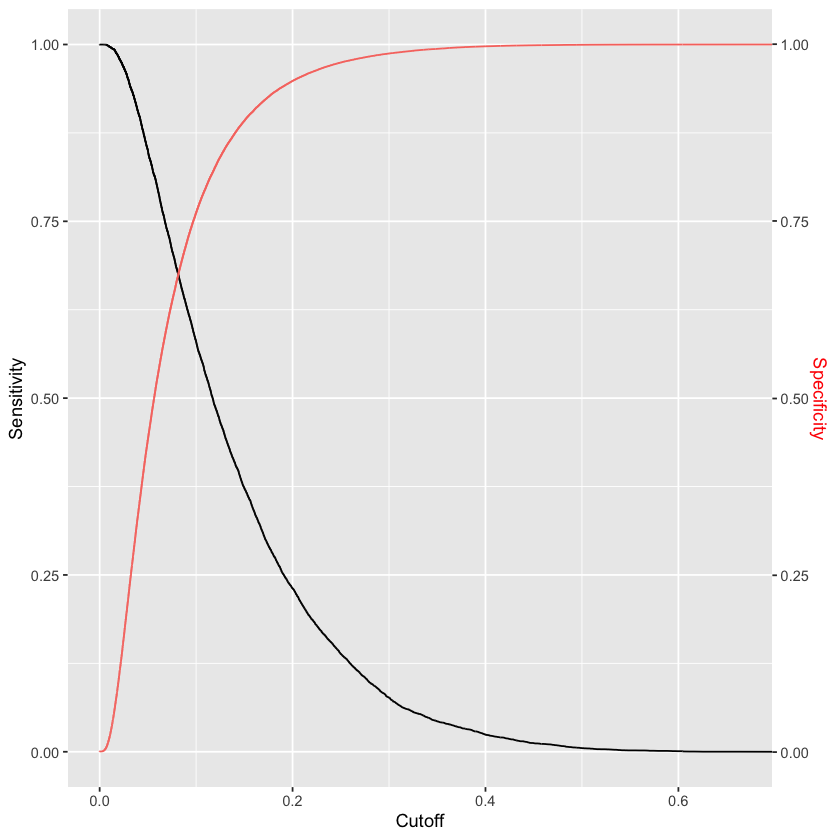

In [38]:
pred <- predict(model, newdata = training, type="raw")
predictions <- prediction(pred,actual) 

sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))

sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=spec, aes(x,y,col="red")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Specificity")) +
  labs(x='Cutoff', y="Sensitivity") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none")

pred2 <- predict(model, newdata = training, type="raw")
pred2 = ifelse(pred)


In [ ]:
fit = svm(factor(Default) ~ ., data = training, scale = TRUE, kernel = "radial", cost = 5)

In [32]:
training_enet = model.matrix(Default ~ . , data = data)
actual = as.factor(data$Default)

# fit = glmnet(training_enet, data$Default, family="binomial")

weights = 1 / (table(actual)[actual] / length(actual))
alpha = c(1, .75, .25, 0)

cvfit = cv.glmnet(training_enet, data$Default, family = "binomial", type.measure = "class", weights=weights)
plot(cvfit)

[1] 0.002963729

[1] 0.0001375641

Confusion Matrix and Statistics

   actual
        0     1
  0 74537  3174
  1 37474  6671
                                          
               Accuracy : 0.6664          
                 95% CI : (0.6638, 0.6691)
    No Information Rate : 0.9192          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1325          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.67760         
            Specificity : 0.66544         
         Pos Pred Value : 0.15112         
         Neg Pred Value : 0.95916         
             Prevalence : 0.08079         
         Detection Rate : 0.05474         
   Detection Prevalence : 0.36227         
      Balanced Accuracy : 0.67152         
                                          
       'Positive' Class : 1               
                                          

Confusion Matrix and Statistics

   actual
        0     1
  0 75220  3167
  1 36791  6678
                                          
               Accuracy : 0.6721          
                 95% CI : (0.6694, 0.6747)
    No Information Rate : 0.9192          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1368          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.67831         
            Specificity : 0.67154         
         Pos Pred Value : 0.15363         
         Neg Pred Value : 0.95960         
             Prevalence : 0.08079         
         Detection Rate : 0.05480         
   Detection Prevalence : 0.35672         
      Balanced Accuracy : 0.67493         
                                          
       'Positive' Class : 1               
                                          

<sparse>[ <logic> ] : .M.sub.i.logical() maybe inefficient

<sparse>[ <logic> ] : .M.sub.i.logical() maybe inefficient



1.859581e+00
-9.925452e-07
3.070867e-02
2.269518e-02
1.249559e-05
2.228588e-02
-4.605595e-02
6.660815e-02
4.610277e-01
-2.224919e-01
1.757407e-01


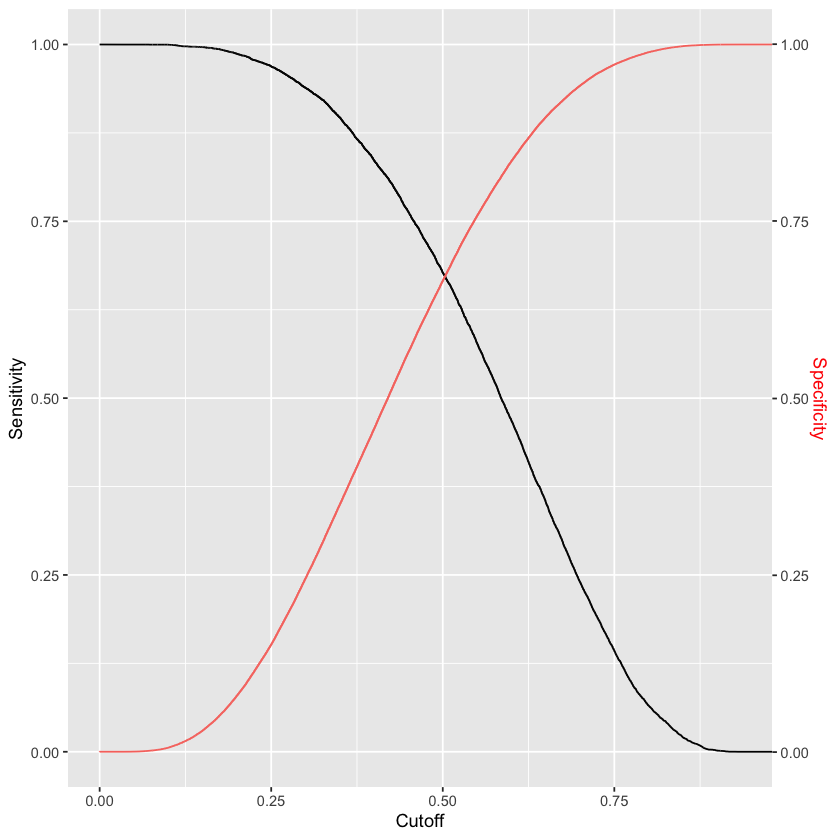

In [31]:
cvfit$lambda.1se
cvfit$lambda.min

pred = predict(cvfit, newx = training_enet, type = "response", s = c(cvfit$lambda.1se, cvfit$lambda.min))
pred_class = predict(cvfit, newx = training_enet, type = "class", s = c(cvfit$lambda.1se, cvfit$lambda.min))

levels(pred_class[,1]) = c(0,1)
levels(pred_class[,2]) = c(0,1)
levels(actual) = c(0,1)
caret::confusionMatrix(table(pred_class[,1], actual), positive = "1")
caret::confusionMatrix(table(pred_class[,2], actual), positive = "1")

predictions <- prediction(pred[,1],actual) 

sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))

sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=spec, aes(x,y,col="red")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Specificity")) +
  labs(x='Cutoff', y="Sensitivity") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none")

# as.matrix(c(names(coef(cvfit)[coef(cvfit) != 0]), coef(cvfit)[coef(cvfit) != 0]))